[np.float64(0.0), np.float64(0.5774), np.float64(0.9107), np.float64(1.5773)]


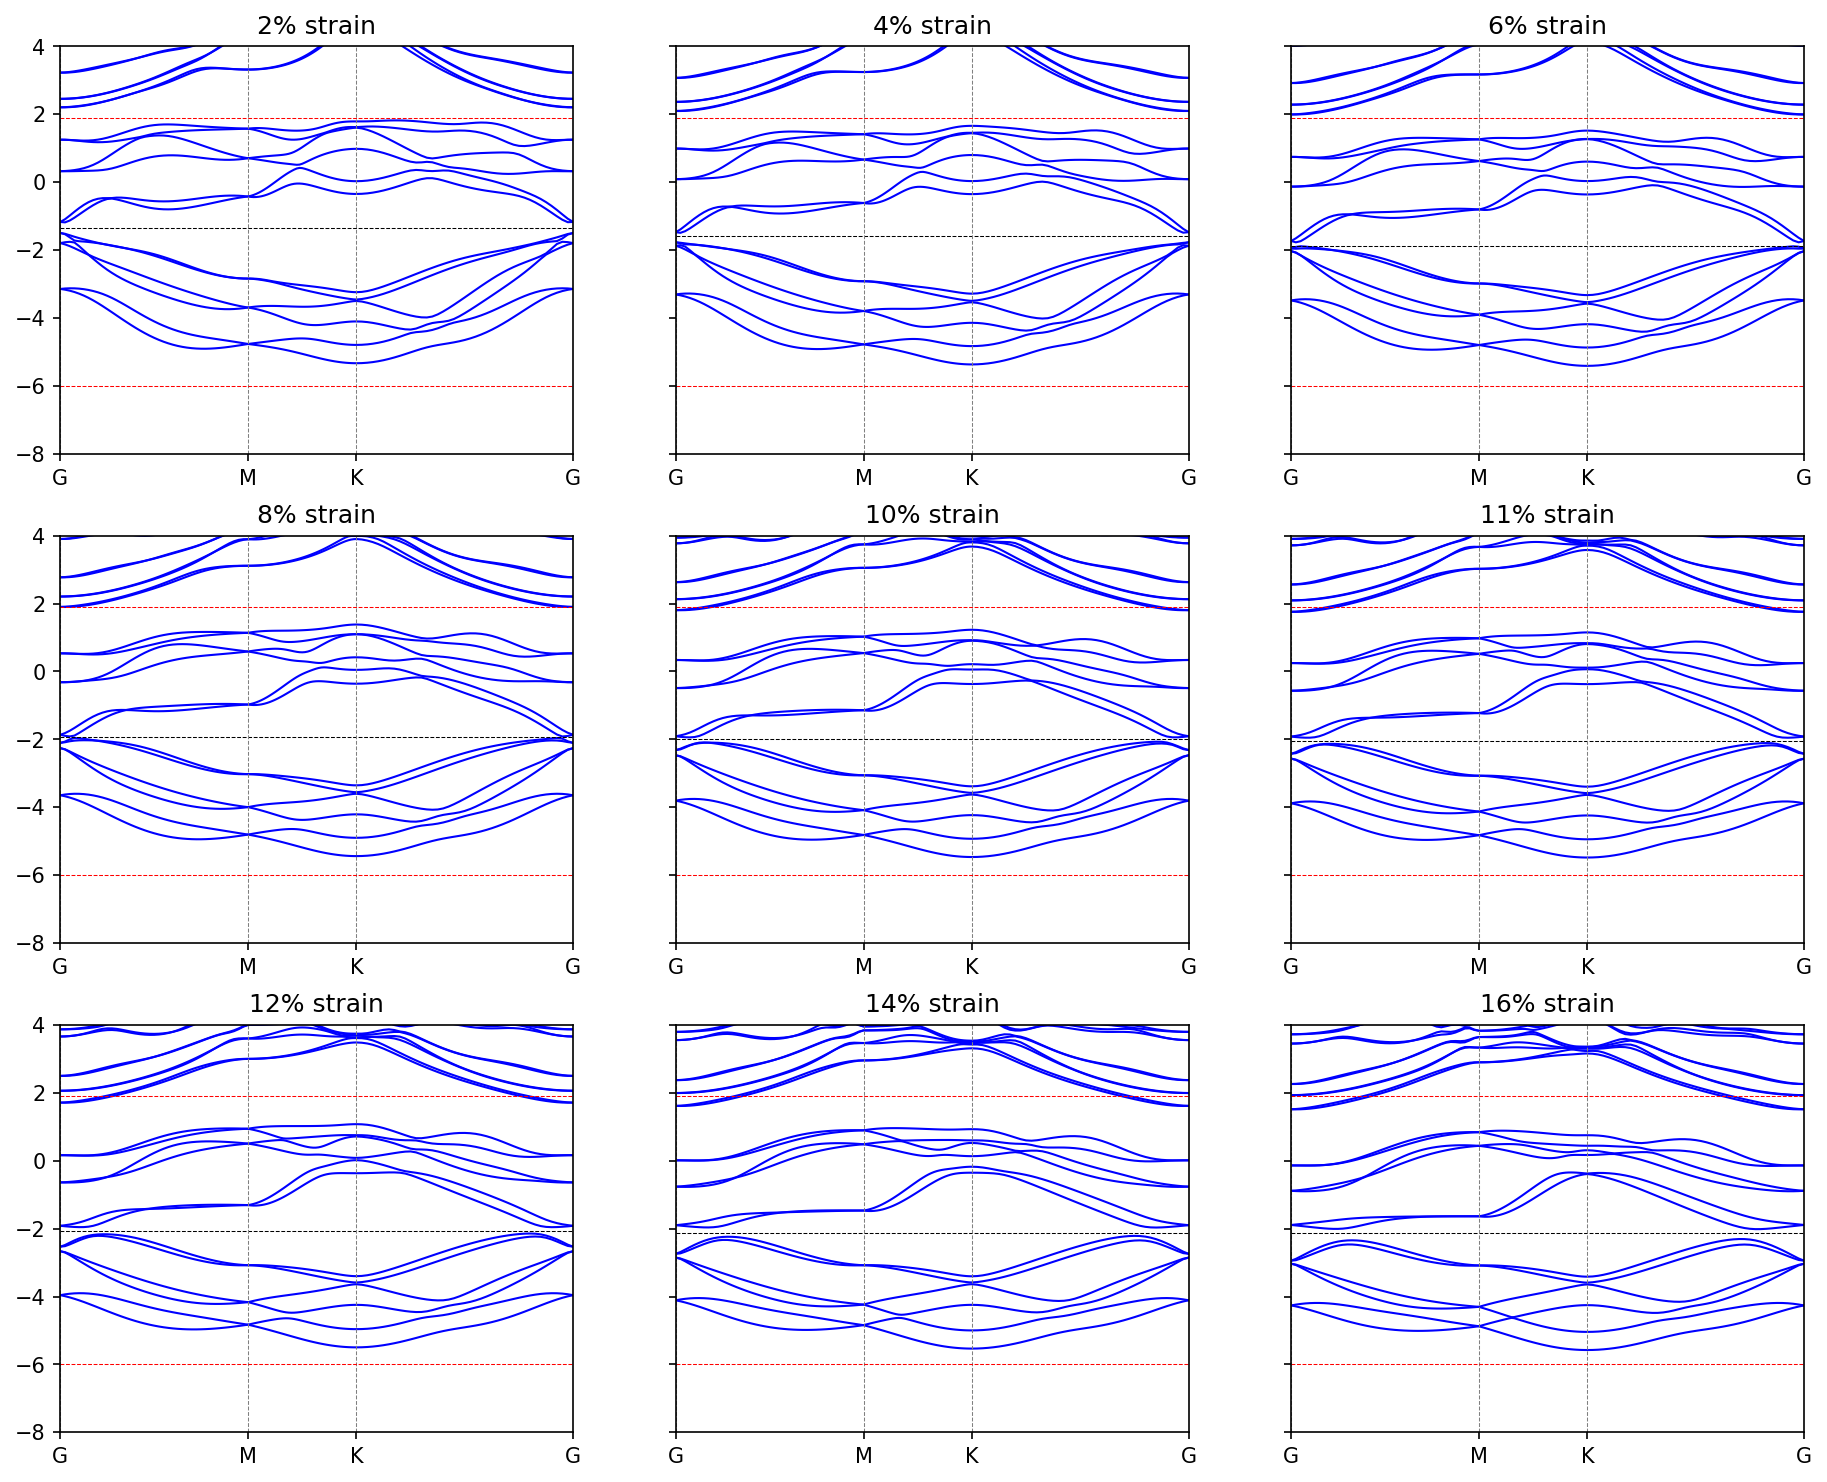

In [9]:
import matplotlib.pyplot as plt
from matplotlib import rcParamsDefault
import numpy as np
%matplotlib inline

plt.rcParams["figure.dpi"]=150
plt.rcParams["figure.facecolor"]="white"
plt.rcParams["figure.figsize"]=(8, 6)

strains = [2,4,6,8,10,11,12,14,16]

fermi_levels = np.loadtxt("fermi_levels.dat")
fermi_levels = fermi_levels.T
fermi_dict = dict(zip(fermi_levels[0].astype(int), fermi_levels[1]))

high_sym_points = [fermi_levels[2][0],fermi_levels[3][0],fermi_levels[4][0],fermi_levels[5][0]]
high_sym_labels = ["G","M","K","G"]
print(high_sym_points)

n_plots = len(strains)
n_cols = 3
n_rows = int(np.ceil(n_plots / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows),
                          sharey=True)
axes = axes.flatten()

datasets = {i: np.loadtxt(f"BiSb_{i}pct.bands.dat.gnu") for i in strains}

for ax, (idx, data) in zip(axes, datasets.items()):
# load data
    k = np.unique(data[:, 0])
    bands = np.reshape(data[:, 1], (-1, len(k)))
    for band in range(len(bands)):
        ax.plot(k, bands[band, :] , linewidth=1, color='blue')
    ax.set_xlim(min(k), max(k))
    ax.axhline(fermi_dict[idx],color="black",lw=0.5,ls="--")
    for i in high_sym_points:
        ax.axvline(i,lw=0.5,ls="--",color="gray")
    ax.set_xticks(high_sym_points,high_sym_labels)
    ax.set_ylim(-8,4)
    ax.set_title(f"{idx}% strain")
    ax.axhline(1.9,color="red",lw=0.5,ls="--")
    ax.axhline(-6,color="red",lw=0.5,ls="--")

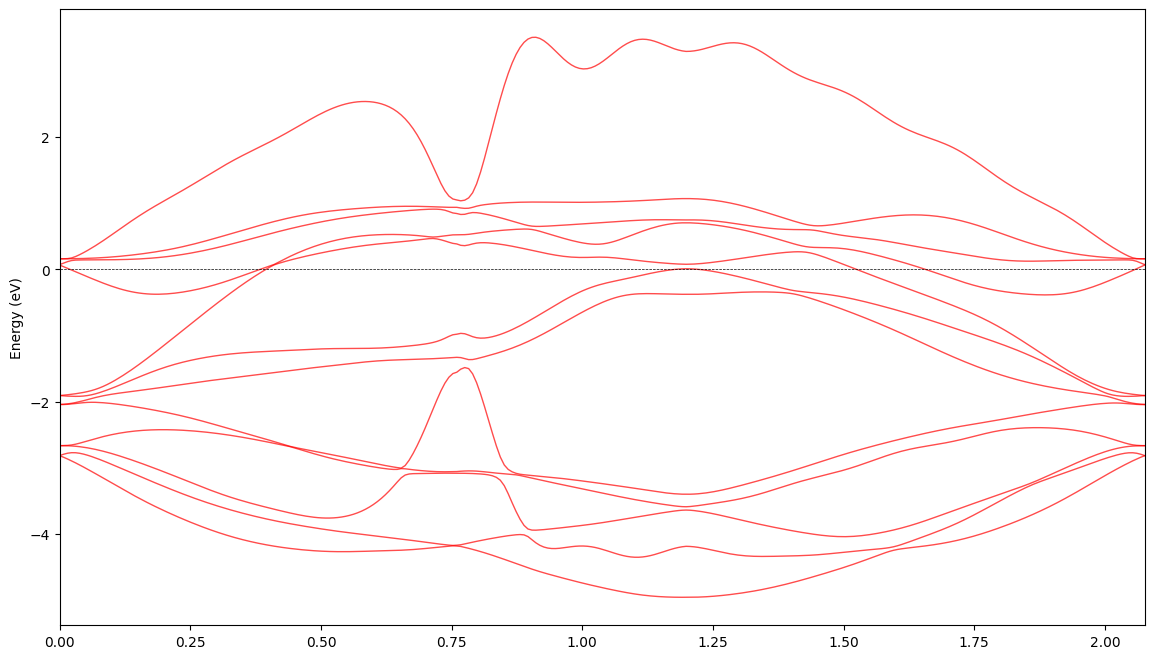

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParamsDefault
import numpy as np


data = np.loadtxt('wannier90_band.dat')

k = np.unique(data[:, 0])
bands = np.reshape(data[:, 1], (-1, len(k)))



plt.figure(figsize=(14, 8))

for band in range(len(bands)):
    plt.plot(k, bands[band, :], linewidth=1, alpha=0.7, color='red')
plt.xlim(min(k), max(k))

plt.axhline(0, color='black', linestyle='--', lw=0.5)

plt.ylabel("Energy (eV)")
#plt.ylim(-5,5)
plt.show()


+----------------------------------------------------------------------+
| ===================                                                  |
| SURFACE CALCULATION                                                  |
| ===================                                                  |
| starting at 2026-06-11 14:21:48,517                                  |
| running Z2Pack version 2.2.1                                         |
|                                                                      |
| gap_tol:            0.3                                              |
| init_result:        None                                             |
| iterator:           range(30, 101, 5)                                |
| load:               False                                            |
| load_quiet:         True                                             |
| min_neighbour_dist: 0.01                                             |
| move_tol:           0.3                         

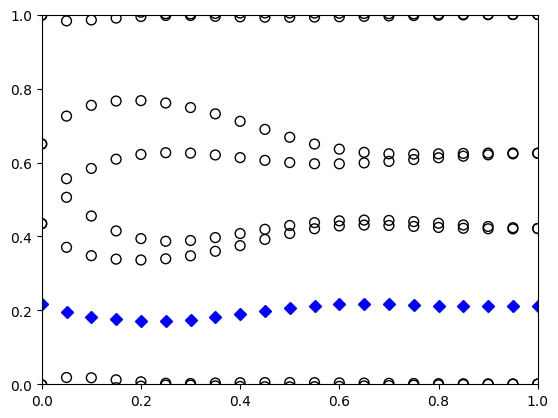

In [6]:
import z2pack
import tbmodels # type: ignore
import matplotlib.pyplot as plt

model = tbmodels.Model.from_wannier_files(hr_file='wannier90_hr.dat', wsvec_file='wannier90_wsvec.dat',occ=6)

system = z2pack.tb.System(model)
result = z2pack.surface.run(system=system, surface=lambda t1,t2: [t1/2, t2, 0.0],num_lines=21,iterator=range(30, 101, 5))

z2pack.plot.wcc(result)
print(z2pack.invariant.z2(result))
plt.show()